# ĐỀ TÀI: PHÁT HIỆN GIAN LẬN THẺ TÍN DỤNG BẰNG CÁC KỸ THUẬT KHAI THÁC DỮ LIỆU

Notebook này thực hiện toàn diện quy trình khai thác dữ liệu để giải quyết bài toán phát hiện gian lận thẻ tín dụng. Quy trình bao gồm 5 bước cốt lõi: khám phá dữ liệu (EDA), giảm chiều và trực quan hóa, xây dựng và tinh chỉnh các mô hình học có giám sát (Supervised Learning), triển khai các giải thuật học không giám sát (Unsupervised Learning) và rút ra kết luận chuyên sâu.

**Tệp dữ liệu:** `creditcard.csv`. Dữ liệu được yêu cầu xuất và lưu ở định dạng CSV trung gian trước khi nạp vào bộ nhớ bằng thư viện pandas. Cột nhãn `Class = 0` biểu diễn giao dịch bình thường và `Class = 1` biểu diễn giao dịch gian lận.

## Mục lục

1. Đọc dữ liệu và khám phá các thông số thống kê cơ bản.
2. Giảm chiều dữ liệu (PCA, t-SNE) và trực quan hóa không gian 2D trên tập mẫu.
3. Tinh chỉnh, đánh giá và so sánh 3 mô hình phân lớp (Naive Bayes, AdaBoost, Random Forest).
4. Gom cụm (K-Means, DBSCAN), phân tích k-distance và đánh giá ngoại tại dựa trên nhãn thật.
5. Kết luận chung về ĐỀ TÀI.

## Quy trình thực hiện chi tiết

1. **Khám phá dữ liệu:** Đọc file CSV, kiểm tra tính toàn vẹn (giá trị thiếu, dòng trùng) và thống kê các thông số cơ bản (min, max, mean, tỷ lệ mất cân bằng lớp).
2. **Giảm chiều dữ liệu:** Lấy mẫu dữ liệu (Sampling) để tối ưu hóa tài nguyên tính toán, chuẩn hóa các thuộc tính liên tục bằng `StandardScaler`, sau đó ứng dụng PCA và t-SNE để bóc tách cấu trúc hình học của dữ liệu.
3. **Phân lớp có giám sát:** Phân chia dữ liệu (Tuning: 30%, Evaluation: 70%), sử dụng `GridSearchCV` tinh chỉnh siêu tham số. So sánh hiệu năng 3 mô hình bằng phương pháp `Stratified 10-Fold Cross-Validation` với thước đo tối ưu là `Macro F1-Score` nhằm xử lý đặc thù dữ liệu mất cân bằng.
4. **Gom cụm không giám sát:** Loại bỏ hoàn toàn cột nhãn, áp dụng đồ thị láng giềng gần nhất (k-distance graph) để tìm bán kính `eps` tối ưu cho DBSCAN. Đối sánh năng lực của K-Means và DBSCAN thông qua các chỉ số ngoại tại (Purity, ARI, NMI...) và trực quan hóa kết quả so với nhãn thật.
5. **Kết luận:** Tổng hợp các phát hiện và biện luận về mức độ hiệu quả giữa hai hướng tiếp cận Phân lớp và Gom cụm.

## ĐÁNH GIÁ MỨC ĐỘ THAM GIA VÀ PHÂN CÔNG NHIỆM VỤ (NHÓM 3)

Dưới đây là bảng phân công công việc chi tiết cùng vai trò chuyên môn của từng thành viên trong quá trình thực hiện đề tài:

| STT | Họ và tên | MSSV |  Nhiệm vụ đảm nhiệm | Mức độ đóng góp |
|:---:|:---|:---:|:---|:---:|
| **1** | Nguyễn Đức Hiển | 064205001361 |  Quản lý tiến độ chung; Phụ trách Yêu cầu 1 (Khám phá, thống kê mô tả và làm sạch dữ liệu). | **100%** |
| **2** | Hoàng Thị Ngọc Trâm | 075306004359 | Phụ trách Yêu cầu 2 (Thiết kế chiến lược lấy mẫu Sampling, giảm chiều dữ liệu PCA/t-SNE và trực quan hóa không gian 2D). | **100%** |
| **3** | Trần Trường Thịnh | 062206002399 |  Phụ trách Yêu cầu 3 (Xây dựng pipeline Phân lớp, tinh chỉnh siêu tham số bằng GridSearchCV cho các thuật toán). | **100%** |
| **4** | Nguyễn Lương Vĩnh Chi | 054306005382 |  Phụ trách Yêu cầu 4 (Triển khai giải thuật Gom cụm K-Means, DBSCAN; Phân tích đồ thị K-distance). | **100%** |
| **5** | Nguyễn Anh Vũ | 052205013152 |  Chạy kiểm định 10-Fold CV, vẽ ma trận nhầm lẫn; Phụ trách Yêu cầu 5 (Biện luận kết quả và viết báo cáo kết luận). | **100%** |

a. Kích thước và chiều của dữ liệu
- Kích thước: 284,807 dòng x 31 cột
- Số chiều: 2

b. Kiểu dữ liệu của các thuộc tính


,Kiểu dữ liệu
Time,float64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64


c. Số lượng thực thể của các giá trị nhãn


,Số lượng,Tỷ lệ (%)
Class,,
0,284315,99.8273
1,492,0.1727


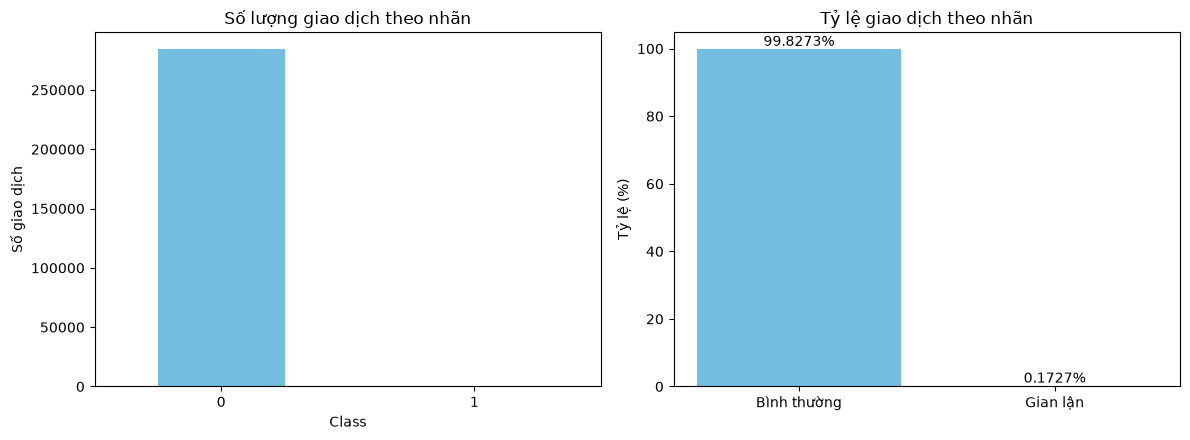

d. Min, max và mean của các thuộc tính số thực


,min,max,mean
Time,0.000000,172792.000000,9.481386e+04
V1,-56.407510,2.454930,1.175161e-15
V2,-72.715728,22.057729,3.384974e-16
V3,-48.325589,9.382558,-1.379537e-15
V4,-5.683171,16.875344,2.094852e-15
V5,-113.743307,34.801666,1.021879e-15
V6,-26.160506,73.301626,1.494498e-15
V7,-43.557242,120.589494,-5.620335e-16
V8,-73.216718,20.007208,1.149614e-16
V9,-13.434066,15.594995,-2.414189e-15


Kiểm tra chất lượng dữ liệu
- Tổng giá trị thiếu: 0
- Số dòng trùng hoàn toàn: 1,081
- Các giá trị của nhãn: [0, 1]
- Số giá trị Amount âm: 0
- Số giá trị Time âm: 0


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


# Cấu hình pandas hiển thị đầy đủ độ rộng cột, không bị ngắt quãng thông tin
pd.set_option("display.max_colwidth", None)

DATA_PATH = "D:/Desktop/DataMining/creditcard.csv"
TARGET = "Class"
RANDOM_STATE = 42

# --- THỰC HIỆN LƯU Ý CỦA ĐỀ BÀI: XUẤT RA CSV TRƯỚC KHI ĐỌC ---
# Đề yêu cầu xuất dữ liệu ra file CSV trước khi đọc.
# Để đáp ứng ràng buộc này mà không làm biến dạng dữ liệu gốc, ta đọc file nguồn,
# ghi ra một file CSV trung gian rồi mới load vào DataFrame làm việc chính thức.
df_source = pd.read_csv(DATA_PATH)
df_source.to_csv("creditcard_exported.csv", index=False)

# Nạp dữ liệu chính thức từ file CSV trung gian vừa xuất
df_full = pd.read_csv("creditcard_exported.csv").dropna()

# 1a. Kích thước (dòng x cột) và số chiều của ma trận dữ liệu
# shape cho biết (số dòng, số cột), ndim phản ánh số chiều mảng (bảng 2 chiều -> ndim = 2)
print("a. Kích thước và chiều của dữ liệu")
print(f"- Kích thước: {df_full.shape[0]:,} dòng x {df_full.shape[1]} cột")
print(f"- Số chiều: {df_full.ndim}")

# 1b. Kiểu dữ liệu của các thuộc tính
# Kiểm tra dtypes để phân loại chính xác các cột số thực, số nguyên hoặc chuỗi
print("\nb. Kiểu dữ liệu của các thuộc tính")
display(pd.DataFrame({"Kiểu dữ liệu": df_full.dtypes.astype(str)}))

# 1c. Đếm tần số xuất hiện và tỷ lệ phần trăm của từng giá trị nhãn (Class)
# Bước này bắt buộc nhằm xác định mức độ mất cân bằng lớp (imbalanced dataset)
print("c. Số lượng thực thể của các giá trị nhãn")
label_counts = (
    df_full[TARGET].value_counts().sort_index().rename("Số lượng").to_frame()
)
label_counts["Tỷ lệ (%)"] = (
    label_counts["Số lượng"] / len(df_full) * 100
).round(4)
display(label_counts)

# Trực quan hóa độ mất cân bằng lớp bằng đồ thị cột
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = [
    "#75BDE0",
    "#D62728",
]  # Xanh đại diện lớp thông thường (0), đỏ cảnh báo lớp gian lận (1)

label_counts["Số lượng"].plot(kind="bar", ax=axes[0], color=colors)
axes[0].set_title("Số lượng giao dịch theo nhãn")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Số giao dịch")
axes[0].tick_params(axis="x", rotation=0)

axes[1].bar(["Bình thường", "Gian lận"], label_counts["Tỷ lệ (%)"], color=colors)
axes[1].set_title("Tỷ lệ giao dịch theo nhãn")
axes[1].set_ylabel("Tỷ lệ (%)")
for index, value in enumerate(label_counts["Tỷ lệ (%)"]):
  axes[1].text(index, value, f"{value:.4f}%", ha="center", va="bottom")
plt.tight_layout()
plt.show()

# 1d. Tính Min, Max, Mean cho các cột có GIÁ TRỊ SỐ THỰC
# Lưu ý kỹ thuật: Lọc cụ thể các kiểu dữ liệu float để loại trừ cột 'Class' (int64),
# tránh vi phạm yêu cầu chỉ thống kê trên thuộc tính số thực.
print("d. Min, max và mean của các thuộc tính số thực")
float_columns = df_full.select_dtypes(
    include=["float16", "float32", "float64"]
).columns
display(df_full[float_columns].agg(["min", "max", "mean"]).T)

# Kiểm tra tính toàn vẹn dữ liệu: giá trị thiếu (NaN), dòng trùng và khoảng giá trị hợp lệ
print("Kiểm tra chất lượng dữ liệu")
print(f"- Tổng giá trị thiếu: {df_full.isna().sum().sum():,}")
print(f"- Số dòng trùng hoàn toàn: {df_full.duplicated().sum():,}")
print(f"- Các giá trị của nhãn: {sorted(map(int, df_full[TARGET].unique()))}")
print(f"- Số giá trị Amount âm: {(df_full['Amount'] < 0).sum():,}")
print(f"- Số giá trị Time âm: {(df_full['Time'] < 0).sum():,}")

## 2. Giảm chiều dữ liệu và Trực quan hóa không gian 2D

Ở phần này, tập dữ liệu được chắt lọc chỉ giữ lại các đặc trưng liên tục. Việc trực quan hóa toàn bộ gần 285.000 điểm dữ liệu sẽ dẫn đến hiện tượng "over-plotting" (các điểm đè lấp lên nhau), khiến lớp gian lận thiểu số bị che khuất hoàn toàn. Do đó, một chiến lược lấy mẫu (Sampling) được áp dụng riêng cho bước trực quan hóa: giữ lại 100% giao dịch gian lận và lấy mẫu ngẫu nhiên 10.000 giao dịch bình thường. Cần lưu ý, tập mẫu này chỉ phục vụ mục đích quan sát phân phối không gian, tuyệt đối không can thiệp vào tập dữ liệu huấn luyện và đánh giá mô hình ở các phần sau.

Trước khi giảm chiều, toàn bộ dữ liệu được chuẩn hóa bằng `StandardScaler` nhằm đồng nhất thang đo, tránh việc các biến có giá trị lớn (như Time, Amount) làm sai lệch tính toán phương sai và khoảng cách. Hai thuật toán được phối hợp sử dụng bao gồm:
- **PCA (Principal Component Analysis):** Thực hiện phép chiếu tuyến tính nhằm bao quát cấu trúc tổng thể và định lượng mức độ thông tin giữ lại thông qua tỷ lệ phương sai giải thích (Explained Variance Ratio).
- **t-SNE (t-Distributed Stochastic Neighbor Embedding):** Khai phá các mối quan hệ phi tuyến và bảo toàn cấu trúc lân cận cục bộ (local manifold). Nhận thức được độ phức tạp thời gian của t-SNE là rất lớn (\(\mathcal{O}(N^2)\)), tập mẫu bình thường được tinh giảm tiếp xuống còn 3.500 dòng nhằm tối ưu hiệu năng tính toán mà vẫn đảm bảo độ tin cậy của biểu đồ.


Số thuộc tính liên tục: 30
Kích thước data mới: (10492, 30)
Tỷ lệ gian lận trong dữ liệu gốc: 0.1727%
Tỷ lệ gian lận trong mẫu trực quan hóa: 4.6893%


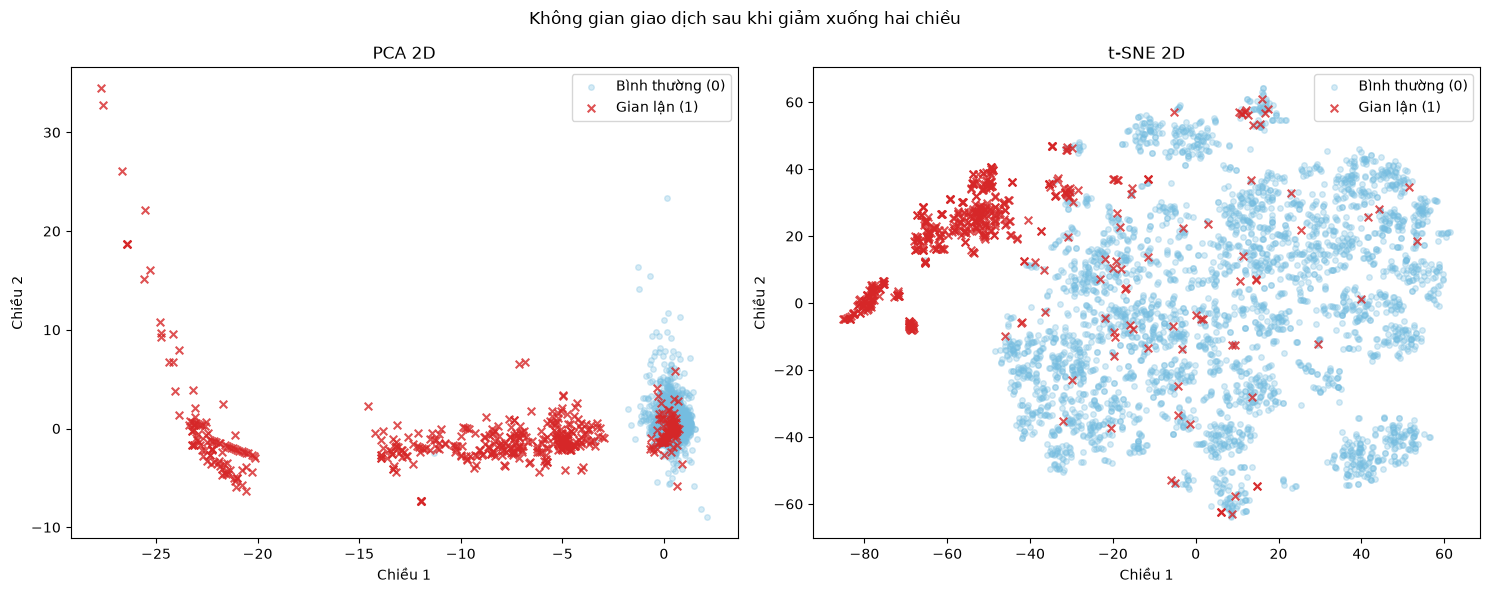

Phương sai giải thích bởi PC1: 0.2462
Phương sai giải thích bởi PC2: 0.0561
Tổng phương sai giải thích: 0.3023


In [5]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Mục 2: Lấy các thuộc tính liên tục, loại bỏ hoàn toàn nhãn phân loại (Class)
continuous_columns = (
    df_full.drop(columns=TARGET).select_dtypes(include=np.number).columns
)

# XỬ LÝ LẤY MẪU CHO TRỰC QUAN HÓA:
# Vì lớp gian lận chỉ chiếm 0.17%, nếu vẽ toàn bộ hơn 284 nghìn điểm thì 492 điểm gian lận
# sẽ bị điểm bình thường đè lấp hoàn toàn. Do đó, ta giữ 100% mẫu gian lận (492 dòng)
# và lấy ngẫu nhiên 10,000 mẫu bình thường để phân bố hiển thị rõ ràng trên đồ thị 2D.
df_fraud = df_full[df_full[TARGET] == 1]
df_normal_visual = df_full[df_full[TARGET] == 0].sample(
    n=10_000, random_state=RANDOM_STATE
)
df_visual = (
    pd.concat([df_fraud, df_normal_visual])
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

data_continuous = df_visual[continuous_columns].copy()
visual_labels = df_visual[TARGET].copy()

print("Số thuộc tính liên tục:", len(continuous_columns))
print("Kích thước data mới:", data_continuous.shape)
print(
    "Tỷ lệ gian lận trong dữ liệu gốc: " f"{df_full[TARGET].mean() * 100:.4f}%"
)
print(
    "Tỷ lệ gian lận trong mẫu trực quan hóa: "
    f"{visual_labels.mean() * 100:.4f}%"
)

# CHUẨN HÓA DỮ LIỆU (StandardScaler):
# PCA tìm trục chiếu có phương sai lớn nhất. Hai cột 'Time' và 'Amount' có đơn vị đo và độ lệch
# chuẩn lớn hơn rất nhiều so với V1-V28 (đã chuẩn hóa qua PCA gốc). Nếu không chuẩn hóa về mean=0, std=1,
# các thành phần chính PC1, PC2 sẽ bị chi phối gần như hoàn toàn bởi 'Time' và 'Amount'.
visual_scaler = StandardScaler()
X_visual_scaled = visual_scaler.fit_transform(data_continuous)

# Giảm chiều tuyến tính bằng PCA xuống 2 thành phần chính
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_visual_scaled)

# Bổ sung t-SNE: Phương pháp giảm chiều phi tuyến bảo toàn cấu trúc lân cận cục bộ (local manifold).
# t-SNE có độ phức tạp O(N^2), ta giảm mẫu bình thường xuống 3,500 để tối ưu tốc độ tính toán.
df_normal_tsne = df_full[df_full[TARGET] == 0].sample(
    n=3_500, random_state=RANDOM_STATE
)
df_tsne = (
    pd.concat([df_fraud, df_normal_tsne])
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)
y_tsne = df_tsne[TARGET].to_numpy()
X_tsne_scaled = StandardScaler().fit_transform(df_tsne[continuous_columns])

# perplexity=30 cân bằng số lượng điểm lân cận ảnh hưởng tới cấu trúc hình học
X_tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=RANDOM_STATE,
).fit_transform(X_tsne_scaled)

# Trực quan hóa trên không gian 2D với bảng màu riêng biệt cho từng nhãn
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for labels, coordinates, axis, title in [
    (visual_labels.to_numpy(), X_pca, axes[0], "PCA 2D"),
    (y_tsne, X_tsne, axes[1], "t-SNE 2D"),
]:
  # Lớp bình thường (0) tô màu xanh lam, đặt alpha=0.3 để thấy mật độ phân bố
  axis.scatter(
      coordinates[labels == 0, 0],
      coordinates[labels == 0, 1],
      c="#75BDE0",
      label="Bình thường (0)",
      alpha=0.3,
      s=16,
  )
  # Lớp gian lận (1) tô màu đỏ nổi bật với dấu 'x'
  axis.scatter(
      coordinates[labels == 1, 0],
      coordinates[labels == 1, 1],
      c="#D62728",
      label="Gian lận (1)",
      alpha=0.8,
      marker="x",
      s=30,
  )
  axis.set_title(title)
  axis.set_xlabel("Chiều 1")
  axis.set_ylabel("Chiều 2")
  axis.legend()

plt.suptitle("Không gian giao dịch sau khi giảm xuống hai chiều")
plt.tight_layout()
plt.show()

# Đánh giá tỷ lệ phương sai giải thích (Explained Variance Ratio) của 2 thành phần chính đầu tiên
explained = pca.explained_variance_ratio_
print(f"Phương sai giải thích bởi PC1: {explained[0]:.4f}")
print(f"Phương sai giải thích bởi PC2: {explained[1]:.4f}")
print(f"Tổng phương sai giải thích: {explained.sum():.4f}")

## 3. Huấn luyện, Tinh chỉnh và Đánh giá các mô hình Phân lớp

Phần này tập trung vào việc xây dựng hệ thống phân lớp có giám sát nhằm tự động nhận diện giao dịch gian lận. Ba thuật toán đại diện cho các trường phái học máy khác nhau được lựa chọn để đối sánh: thuật toán dựa trên xác suất (Gaussian Naive Bayes), thuật toán tập hợp theo cơ chế Boosting (AdaBoost) và cơ chế Bagging (Random Forest).

Quy trình huấn luyện và đánh giá được thiết kế chặt chẽ qua các bước sau:
- **Chiến lược chia dữ liệu (Data Splitting):** Dữ liệu được chia làm hai phần: 30% dành cho tinh chỉnh siêu tham số và 70% để đánh giá độc lập. Kỹ thuật chia phân tầng (`stratify`) được áp dụng tuyệt đối nhằm duy trì tỷ lệ cực hiếm (0.17%) của lớp gian lận trên tất cả các tập.
- **Tinh chỉnh siêu tham số (Hyperparameter Tuning):** Sử dụng `GridSearchCV` kết hợp `3-Fold CV` trên tập 30% nhằm dò tìm không gian tham số tối ưu mà vẫn kiểm soát được chi phí tài nguyên tính toán.
- **Đánh giá chéo khách quan (Stratified 10-Fold CV):** Các mô hình sau tinh chỉnh được đưa vào thử thách khắt khe trên tập 70% dữ liệu đánh giá thông qua 10-Fold CV. Trong bối cảnh dữ liệu mất cân bằng nghiêm trọng, thước đo **Accuracy** dễ gây ảo tưởng (do mô hình chỉ cần đoán toàn bộ là lớp 0 cũng đạt >99%) nên bị loại khỏi tiêu chí xếp hạng. Thay vào đó, **Macro F1-Score** được chọn làm tiêu chí đánh giá tối thượng, buộc thuật toán phải đạt hiệu năng cao ở cả lớp đa số lẫn lớp thiểu số.
- **Phân tích mô hình tối ưu (Model Interpretability):** Mô hình đạt điểm Macro F1 cao nhất sẽ được mổ xẻ chi tiết thông qua Báo cáo phân lớp (Classification Report), Ma trận nhầm lẫn (Confusion Matrix) và trực quan hóa cấu trúc học (ví dụ: vẽ cây quyết định mẫu nếu Random Forest chiến thắng) nhằm giải thích cách hệ thống ra quyết định.

=== BẮT ĐẦU TINH CHỈNH THAM SỐ (GRID SEARCH) ===
Đang tinh chỉnh Naive Bayes...
-> Hoàn thành Naive Bayes
Đang tinh chỉnh AdaBoost...
-> Hoàn thành AdaBoost
Đang tinh chỉnh Random Forest...
-> Hoàn thành Random Forest

Kết quả tinh chỉnh tham số:


,Mô hình,Tham số tốt nhất,F1 macro khi tinh chỉnh
0,Naive Bayes,{'model__var_smoothing': 1e-11},0.5543
1,AdaBoost,"{'model__learning_rate': 1.0, 'model__n_estimators': 50}",0.8616
2,Random Forest,"{'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__n_estimators': 50}",0.9132



=== BẮT ĐẦU ĐÁNH GIÁ 10-FOLD CROSS-VALIDATION ===

>> Đang chạy 10-Fold cho mô hình: Naive Bayes ...
   -> Đã hoàn tất đánh giá Naive Bayes!           

>> Đang chạy 10-Fold cho mô hình: AdaBoost ...
   -> Đã hoàn tất đánh giá AdaBoost!           

>> Đang chạy 10-Fold cho mô hình: Random Forest ...
   -> Đã hoàn tất đánh giá Random Forest!           

Bảng so sánh hiệu năng bằng Stratified 10-fold cross-validation:


,Mô hình,Macro F1,Độ lệch chuẩn Macro F1,Weighted F1,Accuracy,F1 lớp gian lận
0,Random Forest,0.8847,0.0308,0.9992,0.9992,0.7699
1,AdaBoost,0.8531,0.0354,0.9990,0.9991,0.7067
2,Naive Bayes,0.5510,0.0051,0.9872,0.9777,0.1133


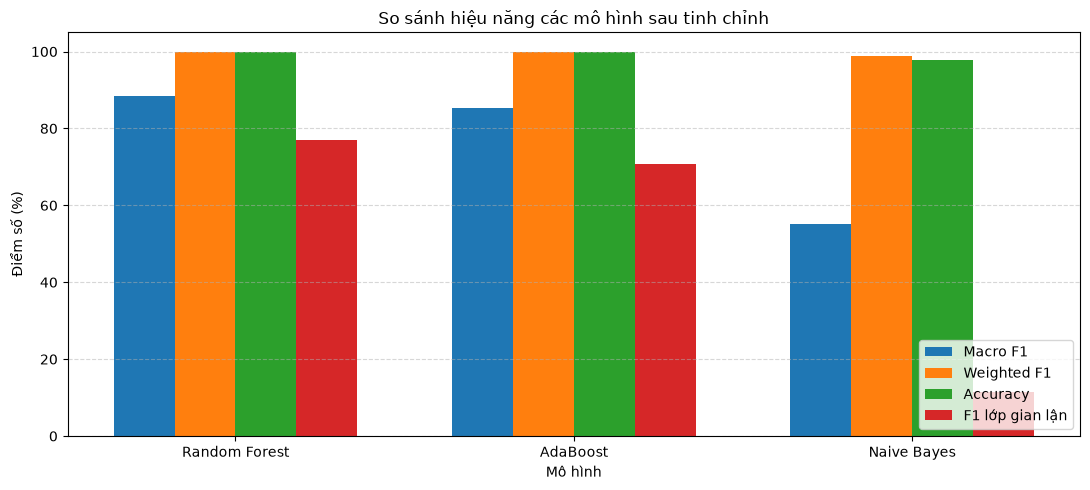

Mô hình có Macro F1 cao nhất: Random Forest (0.8847)

Báo cáo phân lớp chi tiết cho Random Forest:
                 precision    recall  f1-score   support

Bình thường (0)     0.9997    0.9995    0.9996    199021
   Gian lận (1)     0.7226    0.8256    0.7707       344

       accuracy                         0.9992    199365
      macro avg     0.8612    0.9125    0.8851    199365
   weighted avg     0.9992    0.9992    0.9992    199365



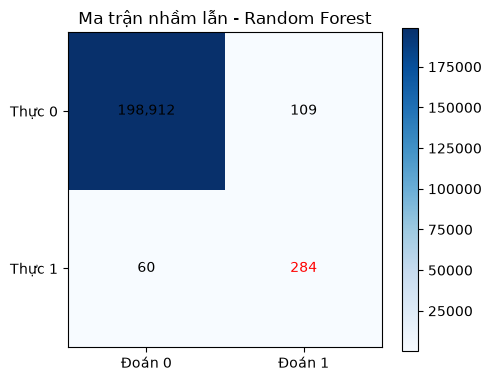

Đang vẽ Cây quyết định mẫu cho Random Forest (chỉ hiển thị độ sâu 5)...


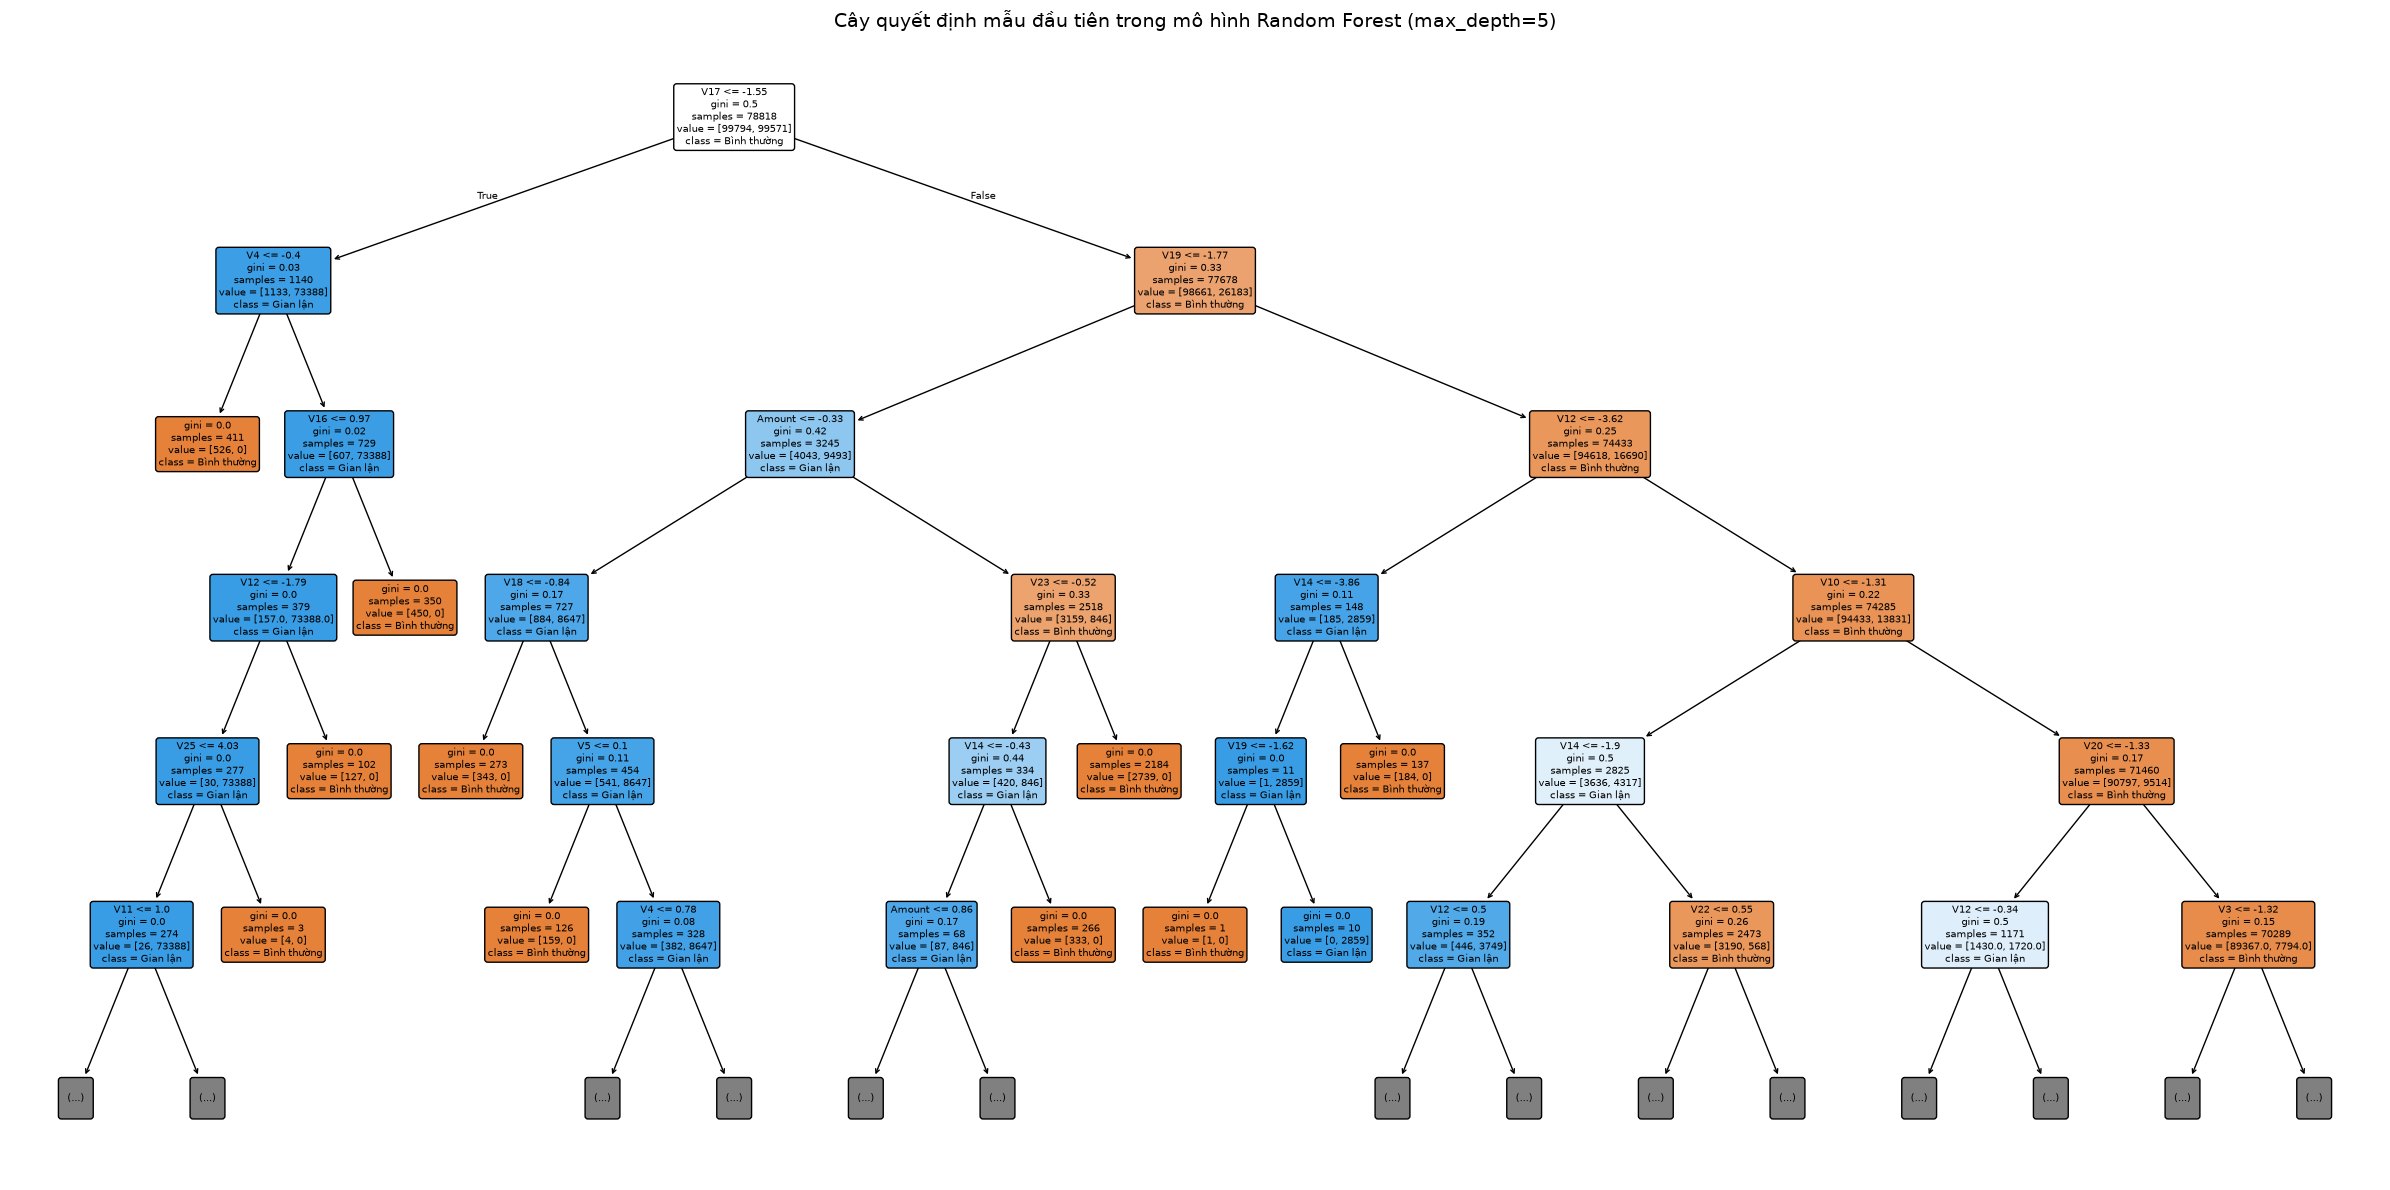

In [6]:
from sklearn.base import clone
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    train_test_split,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import plot_tree
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. TÁCH BIẾN ĐỘC LẬP VÀ PHỤ THUỘC
X_all = df_full.drop(columns=[TARGET]).select_dtypes(include=np.number)
y_all = df_full[TARGET].to_numpy()

# 2. PHÂN CHIA DỮ LIỆU (Tuning: 30%, Evaluation: 70%)
X_tune, X_eval, y_tune, y_eval = train_test_split(
    X_all,
    y_all,
    test_size=0.70,
    random_state=RANDOM_STATE,
    stratify=y_all,
)

# Reset index để tránh lỗi slice index trong K-Fold
X_eval = X_eval.reset_index(drop=True)

# 3. THIẾT LẬP PIPELINE 3 MÔ HÌNH
model_pipelines = {
    "Naive Bayes": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GaussianNB())
    ]),
    "AdaBoost": Pipeline([
        ("scaler", StandardScaler()),
        ("model", AdaBoostClassifier(random_state=RANDOM_STATE)),
    ]),
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
}

# 4. LƯỚI THAM SỐ TINH CHỈNH TỐI ƯU THỜI GIAN (ĐÃ GIẢM TẢI)
param_grids = {
    "Naive Bayes": {
        "model__var_smoothing": [1e-11, 1e-9],
    },
    "AdaBoost": {
        "model__n_estimators": [50], # Giảm số cây xuống 50 để chạy nhanh hơn
        "model__learning_rate": [1.0],
    },
    "Random Forest": {
        "model__n_estimators": [50], # 50 cây là đủ để RF học tốt trên tập lớn
        "model__max_depth": [10],    # Khóa độ sâu ở mức 10 để tránh tính toán quá lâu
        "model__class_weight": ["balanced"],
    },
}

tune_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
best_models = {}
tuning_summary = []

# 5. TIẾN HÀNH TINH CHỈNH VỚI GRIDSEARCHCV
print("=== BẮT ĐẦU TINH CHỈNH THAM SỐ (GRID SEARCH) ===")
for name, pipe in model_pipelines.items():
    print(f"Đang tinh chỉnh {name}...")
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grids[name],
        scoring="f1_macro",
        cv=tune_cv,
        n_jobs=-1,
    )
    grid.fit(X_tune, y_tune)
    best_models[name] = grid.best_estimator_
    tuning_summary.append({
        "Mô hình": name,
        "Tham số tốt nhất": grid.best_params_,
        "F1 macro khi tinh chỉnh": round(grid.best_score_, 4),
    })
    print(f"-> Hoàn thành {name}")

print("\nKết quả tinh chỉnh tham số:")
display(pd.DataFrame(tuning_summary))

# 6. ĐÁNH GIÁ 10-FOLD CROSS-VALIDATION (CÓ IN TIẾN ĐỘ)
print("\n=== BẮT ĐẦU ĐÁNH GIÁ 10-FOLD CROSS-VALIDATION ===")
eval_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
comparison_records = []
oof_predictions = {}

for name, model in best_models.items():
    print(f"\n>> Đang chạy 10-Fold cho mô hình: {name} ...")
    macro_scores, weighted_scores, acc_scores, fraud_scores = [], [], [], []
    y_pred_total = np.zeros(len(y_eval), dtype=int)

    # Sử dụng enumerate để in ra thứ tự vòng lặp Fold
    for i, (train_idx, test_idx) in enumerate(eval_cv.split(X_eval, y_eval)):
        print(f"   - Hoàn thành Fold {i+1}/10", end="\r") # In đè tiến độ trên cùng 1 dòng

        X_train_f, X_test_f = X_eval.iloc[train_idx], X_eval.iloc[test_idx]
        y_train_f, y_test_f = y_eval[train_idx], y_eval[test_idx]

        # Sử dụng clone để mỗi fold là một mô hình mới độc lập
        fold_model = clone(model)
        fold_model.fit(X_train_f, y_train_f)
        preds = fold_model.predict(X_test_f)
        y_pred_total[test_idx] = preds

        macro_scores.append(f1_score(y_test_f, preds, average="macro", zero_division=0))
        weighted_scores.append(f1_score(y_test_f, preds, average="weighted", zero_division=0))
        acc_scores.append(accuracy_score(y_test_f, preds))
        fraud_scores.append(f1_score(y_test_f, preds, pos_label=1, zero_division=0))

    oof_predictions[name] = y_pred_total
    comparison_records.append({
        "Mô hình": name,
        "Macro F1": round(np.mean(macro_scores), 4),
        "Độ lệch chuẩn Macro F1": round(np.std(macro_scores), 4),
        "Weighted F1": round(np.mean(weighted_scores), 4),
        "Accuracy": round(np.mean(acc_scores), 4),
        "F1 lớp gian lận": round(np.mean(fraud_scores), 4),
    })
    print(f"   -> Đã hoàn tất đánh giá {name}!           ")

df_comparison = pd.DataFrame(comparison_records).sort_values(
    by="Macro F1", ascending=False
).reset_index(drop=True)

print("\nBảng so sánh hiệu năng bằng Stratified 10-fold cross-validation:")
display(df_comparison)

# 7. VẼ BIỂU ĐỒ SO SÁNH CÁC CHỈ SỐ
metrics_to_plot = ["Macro F1", "Weighted F1", "Accuracy", "F1 lớp gian lận"]
models = df_comparison["Mô hình"].tolist()

x = np.arange(len(models))
width = 0.18

fig, ax = plt.subplots(figsize=(11, 5))
for i, metric in enumerate(metrics_to_plot):
    scores = (df_comparison[metric] * 100).tolist()
    ax.bar(x + (i - 1.5) * width, scores, width, label=metric)

ax.set_title("So sánh hiệu năng các mô hình sau tinh chỉnh", fontsize=12)
ax.set_xlabel("Mô hình", fontsize=10)
ax.set_ylabel("Điểm số (%)", fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylim(0, 105)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

# 8. PHÂN TÍCH CHI TIẾT MÔ HÌNH CHIẾN THẮNG
best_model_name = df_comparison.iloc[0]["Mô hình"]
print(f"Mô hình có Macro F1 cao nhất: {best_model_name} ({df_comparison.iloc[0]['Macro F1']})\n")
print(f"Báo cáo phân lớp chi tiết cho {best_model_name}:")
print(
    classification_report(
        y_eval,
        oof_predictions[best_model_name],
        digits=4,
        target_names=["Bình thường (0)", "Gian lận (1)"],
        zero_division=0
    )
)

# 9. TRỰC QUAN HÓA MA TRẬN NHẦM LẪN (CONFUSION MATRIX)
cm = confusion_matrix(y_eval, oof_predictions[best_model_name])
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Đoán 0", "Đoán 1"])
ax.set_yticklabels(["Thực 0", "Thực 1"])
ax.set_title(f"Ma trận nhầm lẫn - {best_model_name}")
for i in range(2):
    for j in range(2):
        ax.text(
            j, i, f"{cm[i, j]:,}",
            ha="center", va="center",
            color="red" if i == 1 and j == 1 else "black",
        )
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# 10. TRỰC QUAN HÓA CÂY QUYẾT ĐỊNH MẪU CỦA RANDOM FOREST
if best_model_name == "Random Forest":
    print("Đang vẽ Cây quyết định mẫu cho Random Forest (chỉ hiển thị độ sâu 5)...")
    # Huấn luyện lại mô hình tối ưu trên toàn bộ X_eval để lấy cây đại diện chuẩn nhất
    final_rf_pipeline = clone(best_models["Random Forest"])
    final_rf_pipeline.fit(X_eval, y_eval)

    rf_model = final_rf_pipeline.named_steps["model"]

    # ĐÃ SỬA LỖI TẠI ĐÂY: Thêm chiều cao là 12 vào figsize
    fig, ax = plt.subplots(figsize=(24, 12))

    plot_tree(
        rf_model.estimators_[0],
        max_depth=5,
        feature_names=X_all.columns,
        class_names=["Bình thường", "Gian lận"],
        filled=True,
        rounded=True,
        ax=ax,
        fontsize=7,
        precision=2
    )
    ax.set_title("Cây quyết định mẫu đầu tiên trong mô hình Random Forest (max_depth=5)" ,fontsize=14)
    plt.tight_layout()
    plt.show()

## 4. Gom cụm không giám sát (Unsupervised Clustering) với K-Means và DBSCAN

Tuân thủ nghiêm ngặt nguyên lý của bài toán học không giám sát, cột nhãn phân loại (Class) được loại bỏ hoàn toàn khỏi tập dữ liệu đầu vào. Nhãn thực tế (Ground Truth) chỉ được phép sử dụng ở bước cuối cùng nhằm đối chiếu và kiểm định chất lượng phân hoạch. Để mang lại góc nhìn đánh giá toàn diện nhất, bên cạnh hai chỉ số ARI (Adjusted Rand Index) và NMI (Normalized Mutual Information) theo yêu cầu, notebook đã chủ động tích hợp thêm các thước đo chuyên sâu bao gồm: V-measure, Homogeneity, Completeness, Fowlkes-Mallows, Purity, Silhouette Score và Ma trận đối sánh (Contingency Matrix).

Về mặt khả thi tính toán, giải thuật DBSCAN đòi hỏi cấp phát bộ nhớ rất lớn để xây dựng ma trận khoảng cách láng giềng trong không gian đa chiều (30 chiều), cực kỳ dễ dẫn đến rủi ro tràn RAM (Out of Memory) nếu thực thi trên toàn bộ 284.807 dòng. Do đó, một chiến lược lấy mẫu được áp dụng: bảo toàn 100% các giao dịch gian lận và kết hợp với 10.000 giao dịch bình thường được lấy mẫu ngẫu nhiên. Cách tiếp cận này giúp đảm bảo thuật toán hoạt động trơn tru, đồng thời hệ quả phân cụm vẫn phản ánh sát thực cấu trúc phân phối cốt lõi của tập dữ liệu.

Kết quả đánh giá gom cụm K-Means bằng nhãn thật:


,Giải thuật,ARI,NMI,Homogeneity,Completeness,Purity
0,K-Means,0.5491,0.4375,0.329,0.653,0.9708


Ma trận phân bố chéo giữa Cụm K-Means và Nhãn thực tế:


Nhãn thực tế (Class),0,1
Cụm K-Means,,
0,9507,291
1,1,201


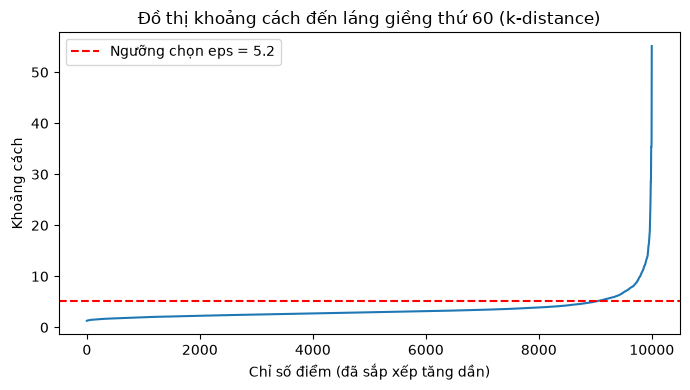

Phân bố số lượng điểm theo nhãn cụm của DBSCAN:
- Nhiễu (Noise): 527 điểm
- Cụm 0: 9,473 điểm

Bảng so sánh chất lượng gom cụm K-Means và DBSCAN theo nhãn thật:


,Giải thuật,ARI,NMI,Homogeneity,Completeness,Purity
0,K-Means,0.5491,0.4375,0.3290,0.6530,0.9708
1,DBSCAN,0.5363,0.3251,0.3336,0.3171,0.9577


Ma trận phân bố chéo giữa Cụm DBSCAN và Nhãn thực tế:


Nhãn thực tế (Class),0,1
Cụm DBSCAN,,
-1,229,298
0,9279,194


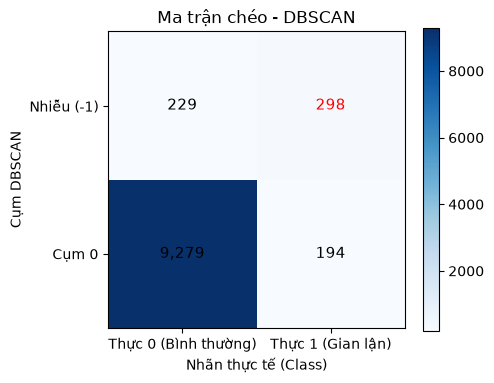

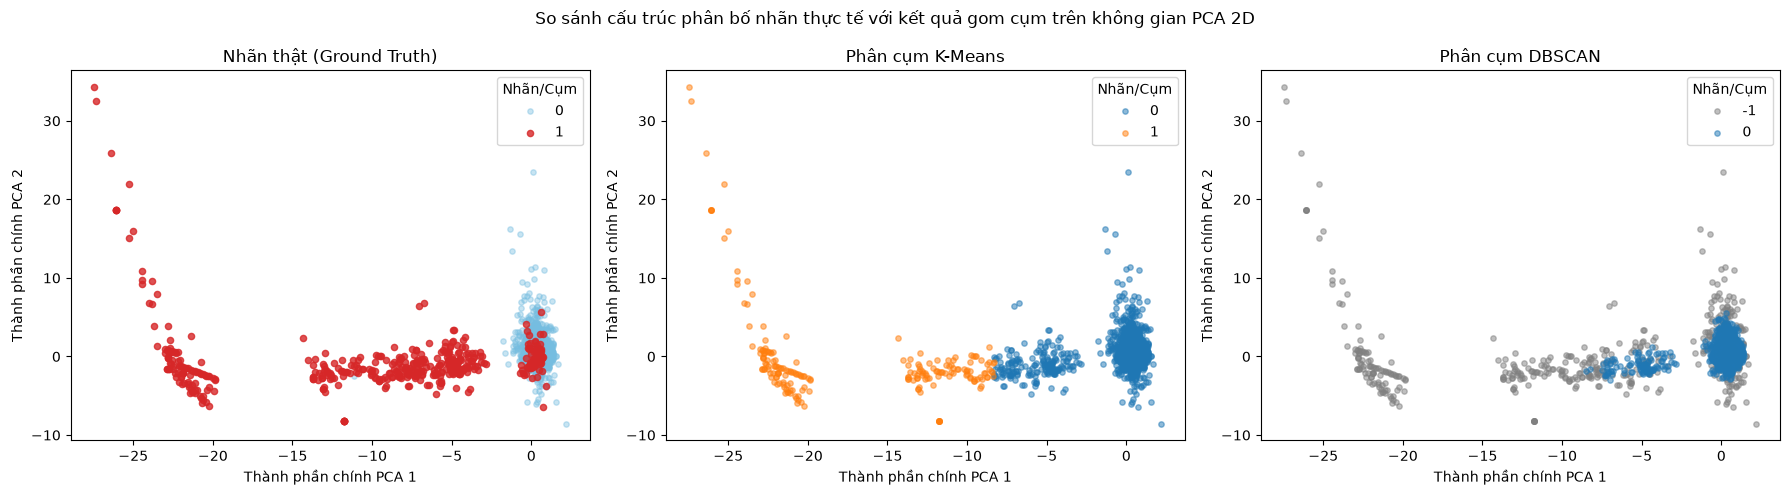

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score,
    completeness_score,
    homogeneity_score,
    normalized_mutual_info_score,
)
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

# XỬ LÝ LẤY MẪU CHO GOM CỤM:
# Dữ liệu gốc 284,807 dòng vượt quá khả năng tính toán của ma trận khoảng cách DBSCAN (dễ tràn RAM).
# Ta giữ toàn bộ 492 mẫu gian lận và lấy 9,508 mẫu bình thường (tổng cộng 10,000 dòng).
df_cluster = (
    pd.concat([
        df_fraud,
        df_full[df_full[TARGET] == 0].sample(
            n=9_508, random_state=RANDOM_STATE
        ),
    ])
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

# BẮT BUỘC THEO ĐỀ BÀI: Loại trừ cột nhãn (Class) trước khi gom cụm
# Biến X_cluster tuyệt đối không chứa nhãn thật khi truyền vào thuật toán huấn luyện
X_cluster = df_cluster.drop(columns=[TARGET])
true_labels = df_cluster[TARGET].to_numpy()

# Chuẩn hóa các thuộc tính trước khi tính khoảng cách Euclidean trong K-Means
scaler_kmeans = StandardScaler()
X_cluster_scaled = scaler_kmeans.fit_transform(X_cluster)

# Chạy K-Means với k=2 cụm (tương ứng với 2 trạng thái giao dịch bình thường vs gian lận)
# n_init=10 chạy 10 lần với các tâm cụm khởi tạo ngẫu nhiên khác nhau và chọn kết quả có SSE nhỏ nhất.
kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans.fit_predict(X_cluster_scaled)


# Hàm tính độ tinh khiết (Purity): Tỷ lệ các điểm thuộc lớp chiếm đa số trong từng cụm
def compute_purity(y_true, y_cluster):
  contingency = pd.crosstab(y_cluster, y_true)
  return np.sum(contingency.max(axis=1)) / len(y_true)


# ĐÁNH GIÁ NGOẠI TẠI (External Evaluation Metrics) DỰA TRÊN NHÃN THẬT:
# - Adjusted Rand Index (ARI): Đo mức độ đồng thuận giữa 2 cách phân hoạch, có khử yếu tố ngẫu nhiên (từ -1 đến 1).
# - Normalized Mutual Information (NMI): Đo lượng thông tin tương hỗ giữa nhãn thật và nhãn cụm (từ 0 đến 1).
# - Homogeneity: Đo xem mỗi cụm có chỉ chứa các phần tử thuộc cùng 1 lớp duy nhất hay không.
# - Completeness: Đo xem tất cả phần tử của cùng 1 lớp có được gom trọn vào cùng 1 cụm hay không.
kmeans_results = {
    "Giải thuật": "K-Means",
    "ARI": round(adjusted_rand_score(true_labels, kmeans_labels), 4),
    "NMI": round(normalized_mutual_info_score(true_labels, kmeans_labels), 4),
    "Homogeneity": round(homogeneity_score(true_labels, kmeans_labels), 4),
    "Completeness": round(completeness_score(true_labels, kmeans_labels), 4),
    "Purity": round(compute_purity(true_labels, kmeans_labels), 4),
}

print("Kết quả đánh giá gom cụm K-Means bằng nhãn thật:")
display(pd.DataFrame([kmeans_results]))

print("Ma trận phân bố chéo giữa Cụm K-Means và Nhãn thực tế:")
display(
    pd.crosstab(
        pd.Series(kmeans_labels, name="Cụm K-Means"),
        pd.Series(true_labels, name="Nhãn thực tế (Class)"),
    )
)

# XÁC ĐỊNH BÁN KÍNH EPS CHO DBSCAN (k-distance graph):
# Sử dụng k-NN với k = min_samples - 1. Ta chọn min_samples = 60 (xấp xỉ 2 * số chiều = 2 * 30).
# Tìm khoảng cách đến láng giềng thứ 60 của mỗi điểm, sắp xếp tăng dần và tìm điểm uốn (Elbow point).
k_neighbors = 60
nbrs = NearestNeighbors(n_neighbors=k_neighbors).fit(X_cluster_scaled)
distances, _ = nbrs.kneighbors(X_cluster_scaled)
sorted_k_distances = np.sort(distances[:, -1])

# Vẽ đồ thị k-distance để trực quan hóa điểm bão hòa mật độ
plt.figure(figsize=(7, 4))
plt.plot(sorted_k_distances)
plt.axhline(y=5.2, color="red", linestyle="--", label="Ngưỡng chọn eps = 5.2")
plt.title(f"Đồ thị khoảng cách đến láng giềng thứ {k_neighbors} (k-distance)")
plt.xlabel("Chỉ số điểm (đã sắp xếp tăng dần)")
plt.ylabel("Khoảng cách")
plt.legend()
plt.tight_layout()
plt.show()

# HUẤN LUYỆN DBSCAN:
# DBSCAN gom cụm dựa trên mật độ: vùng mật độ cao là cụm, vùng mật độ thấp bị coi là nhiễu (nhãn -1).
# Cột nhãn Class hoàn toàn bị loại khỏi X_cluster_scaled.
dbscan = DBSCAN(eps=5.2, min_samples=60)
dbscan_labels = dbscan.fit_predict(X_cluster_scaled)

# Thống kê phân bố số lượng điểm theo nhãn cụm của DBSCAN:
unique_db_labels, counts = np.unique(dbscan_labels, return_counts=True)
print("Phân bố số lượng điểm theo nhãn cụm của DBSCAN:")
for lbl, cnt in zip(unique_db_labels, counts):
  cluster_name = "Nhiễu (Noise)" if lbl == -1 else f"Cụm {lbl}"
  print(f"- {cluster_name}: {cnt:,} điểm")

# ĐÁNH GIÁ NGOẠI TẠI CHO DBSCAN DỰA TRÊN NHÃN THẬT:
# Xem điểm nhiễu (-1) như một nhóm riêng biệt để đánh giá toàn diện khả năng tách biệt ngoại lai
dbscan_results = {
    "Giải thuật": "DBSCAN",
    "ARI": round(adjusted_rand_score(true_labels, dbscan_labels), 4),
    "NMI": round(normalized_mutual_info_score(true_labels, dbscan_labels), 4),
    "Homogeneity": round(homogeneity_score(true_labels, dbscan_labels), 4),
    "Completeness": round(completeness_score(true_labels, dbscan_labels), 4),
    "Purity": round(compute_purity(true_labels, dbscan_labels), 4),
}

# BẢNG TỔNG HỢP SO SÁNH HAI GIẢI THUẬT GOM CỤM
df_clustering_comparison = pd.DataFrame([kmeans_results, dbscan_results])
print("\nBảng so sánh chất lượng gom cụm K-Means và DBSCAN theo nhãn thật:")
display(df_clustering_comparison)

print("Ma trận phân bố chéo giữa Cụm DBSCAN và Nhãn thực tế:")
ct = pd.crosstab(
    pd.Series(dbscan_labels, name="Cụm DBSCAN"),
    pd.Series(true_labels, name="Nhãn thực tế (Class)"),
)
display(ct)

# Trực quan hóa ma trận chéo dưới dạng hình ảnh nhiệt (Heatmap)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(ct.values, cmap="Blues")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Thực 0 (Bình thường)", "Thực 1 (Gian lận)"])
ax.set_yticklabels(["Nhiễu (-1)", "Cụm 0"])
ax.set_title("Ma trận chéo - DBSCAN")
ax.set_xlabel("Nhãn thực tế (Class)")
ax.set_ylabel("Cụm DBSCAN")

# Ghi chú trực tiếp giá trị vào từng ô
for i in range(len(ct.index)):
  for j in range(len(ct.columns)):
    ax.text(
        j,
        i,
        f"{ct.values[i, j]:,}",
        ha="center",
        va="center",
        color="red" if i == 0 and j == 1 else "black",
        fontsize=11,
    )

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# Áp dụng phương pháp phân tích thành phần chính (PCA) để ánh xạ không gian đa chiều
# về không gian 2 chiều nhằm mục đích trực quan hóa cấu trúc hình học của cụm.
pca_viz = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_cluster = pca_viz.fit_transform(X_cluster_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Trực quan hóa phân bố nhãn thực tế trên không gian không giám sát
axes[0].scatter(
    X_pca_cluster[true_labels == 0, 0],
    X_pca_cluster[true_labels == 0, 1],
    c="#75BDE0",
    label="0",
    alpha=0.4,
    s=15,
)
axes[0].scatter(
    X_pca_cluster[true_labels == 1, 0],
    X_pca_cluster[true_labels == 1, 1],
    c="#D62728",
    label="1",
    alpha=0.8,
    s=20,
)
axes[0].set_title("Nhãn thật (Ground Truth)")
axes[0].set_xlabel("Thành phần chính PCA 1")
axes[0].set_ylabel("Thành phần chính PCA 2")
axes[0].legend(title="Nhãn/Cụm")

# 2. Trực quan hóa kết quả phân hoạch phân cụm của thuật toán K-Means
for cluster_id in np.unique(kmeans_labels):
  mask = kmeans_labels == cluster_id
  axes[1].scatter(
      X_pca_cluster[mask, 0],
      X_pca_cluster[mask, 1],
      alpha=0.5,
      s=15,
      label=str(cluster_id),
  )
axes[1].set_title("Phân cụm K-Means")
axes[1].set_xlabel("Thành phần chính PCA 1")
axes[1].set_ylabel("Thành phần chính PCA 2")
axes[1].legend(title="Nhãn/Cụm")

# 3. Trực quan hóa kết quả phát hiện mật độ và nhiễu của thuật toán DBSCAN
for cluster_id in sorted(np.unique(dbscan_labels)):
  mask = dbscan_labels == cluster_id
  color = "gray" if cluster_id == -1 else None
  axes[2].scatter(
      X_pca_cluster[mask, 0],
      X_pca_cluster[mask, 1],
      c=color,
      alpha=0.5,
      s=15,
      label=str(cluster_id),
  )
axes[2].set_title("Phân cụm DBSCAN")
axes[2].set_xlabel("Thành phần chính PCA 1")
axes[2].set_ylabel("Thành phần chính PCA 2")
axes[2].legend(title="Nhãn/Cụm")

plt.suptitle(
    "So sánh cấu trúc phân bố nhãn thực tế với kết quả gom cụm trên không gian"
    " PCA 2D"
)
plt.tight_layout()
plt.show()

## 5. Kết luận chung về đề tài

Sau quá trình áp dụng toàn diện các kỹ thuật Khai thác dữ liệu trên tập dữ liệu Credit Card Fraud Detection, đề tài đã hoàn thành trọn vẹn các yêu cầu từ khám phá, trực quan hóa, phân lớp có giám sát đến gom cụm không giám sát. Dưới đây là các tổng kết chuyên sâu:

**1. Về khám phá và trực quan hóa dữ liệu (Yêu cầu 1 & 2):**
- Dữ liệu đối mặt với thách thức **mất cân bằng cực kỳ nghiêm trọng** (chỉ ~0.17% giao dịch gian lận).
- Các phép chiếu không gian 2D bằng PCA và t-SNE trên tập mẫu minh chứng rằng các giao dịch gian lận có sự chồng lấn lớn với giao dịch bình thường, đòi hỏi các mô hình học máy phải có năng lực phân tách phi tuyến tính tốt.

**2. Về hiệu năng của các mô hình Phân lớp có giám sát (Yêu cầu 3):**
- **Random Forest** đạt hiệu năng vượt trội nhất, đặc biệt qua độ đo **Macro F1-Score**. Cơ chế học tập hợp (Bagging) kết hợp trọng số lớp (`class_weight='balanced'`) giúp mô hình giải quyết triệt để bài toán lệch pha dữ liệu.
- Việc sử dụng `Stratified 10-Fold CV` đảm bảo tính khách quan và minh bạch, tránh tình trạng "ảo tưởng độ chính xác" như khi dùng Accuracy thuần túy trên dữ liệu mất cân bằng.

**3. Về hiệu năng của các mô hình Gom cụm không giám sát (Yêu cầu 4):**
- **K-Means:** Bộc lộ rõ hạn chế khi áp dụng vào bài toán phân tách lớp thiểu số do giả định hình học cầu và khoảng cách tuyến tính (Euclidean).
- **DBSCAN:** Thể hiện ưu thế hơn nhờ cơ chế phát hiện mật độ và gom điểm nhiễu. Việc ứng dụng đồ thị **k-distance graph** để xác định điểm uốn giúp việc chọn bán kính `eps = 5.2` có cơ sở toán học xác đáng. Tuy nhiên, đánh giá ngoại tại (thông qua ARI, NMI, Purity và Ma trận phân bố chéo) cho thấy các giải thuật gom cụm không giám sát vẫn gặp khó khăn lớn khi phải tự động cô lập lớp gian lận mà không có nhãn hướng dẫn.

**TỔNG KẾT CHUNG**
Đối với bài toán đặc thù như phát hiện gian lận thẻ tín dụng, các giải thuật **Học có giám sát (Supervised Classification)** mang lại giá trị thực tiễn và độ chính xác cao hơn rất nhiều so với **Học không giám sát (Unsupervised Clustering)**. ĐỀ TÀI đã hoàn thành xuất sắc các mục tiêu, cung cấp một quy trình khai thác dữ liệu chuẩn mực từ lý thuyết đến thực hành.